### Section 1: Data Loading and Initial Exploration

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
!pip install kaggle
!kaggle datasets download -d roqayyeh/concrete-strength-dataset
!unzip concrete-strength-dataset.zip


Dataset URL: https://www.kaggle.com/datasets/roqayyeh/concrete-strength-dataset
License(s): other
concrete-strength-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  concrete-strength-dataset.zip
replace CocreteStrengthEDA.ipynb? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace ConcreteStrengthData.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


### Section 2: Feature Correlation Analysis

In [ ]:
df = pd.read_csv("ConcreteStrengthData.csv")
df

,CementComponent,BlastFurnaceSlag,FlyAshComponent,WaterComponent,SuperplasticizerComponent,CoarseAggregateComponent,FineAggregateComponent,AgeInDays,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [ ]:
df.describe()

,CementComponent,BlastFurnaceSlag,FlyAshComponent,WaterComponent,SuperplasticizerComponent,CoarseAggregateComponent,FineAggregateComponent,AgeInDays,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


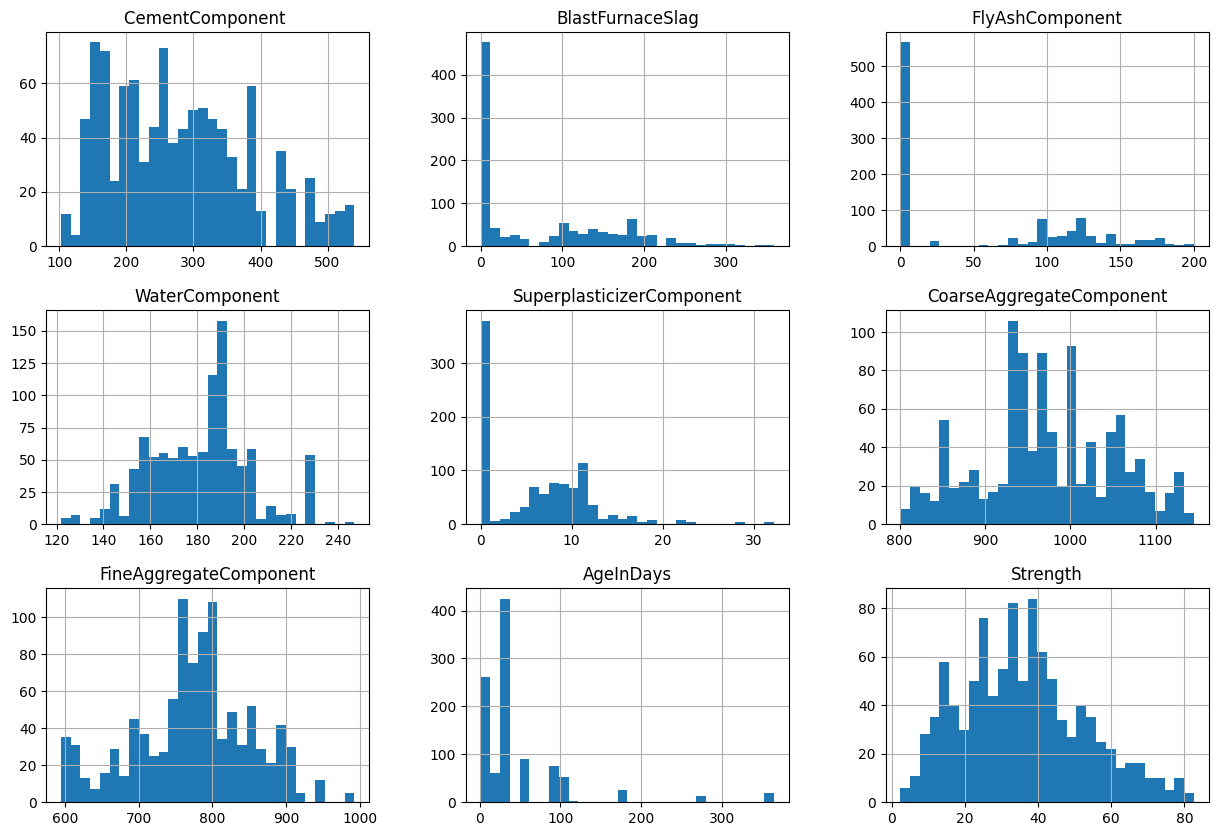

In [ ]:
df.hist(figsize=(15, 10), bins=30)
plt.show()

In [ ]:
df.corr()

,CementComponent,BlastFurnaceSlag,FlyAshComponent,WaterComponent,SuperplasticizerComponent,CoarseAggregateComponent,FineAggregateComponent,AgeInDays,Strength
CementComponent,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
BlastFurnaceSlag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
FlyAshComponent,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
WaterComponent,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
SuperplasticizerComponent,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079
CoarseAggregateComponent,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935
FineAggregateComponent,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241
AgeInDays,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873
Strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000


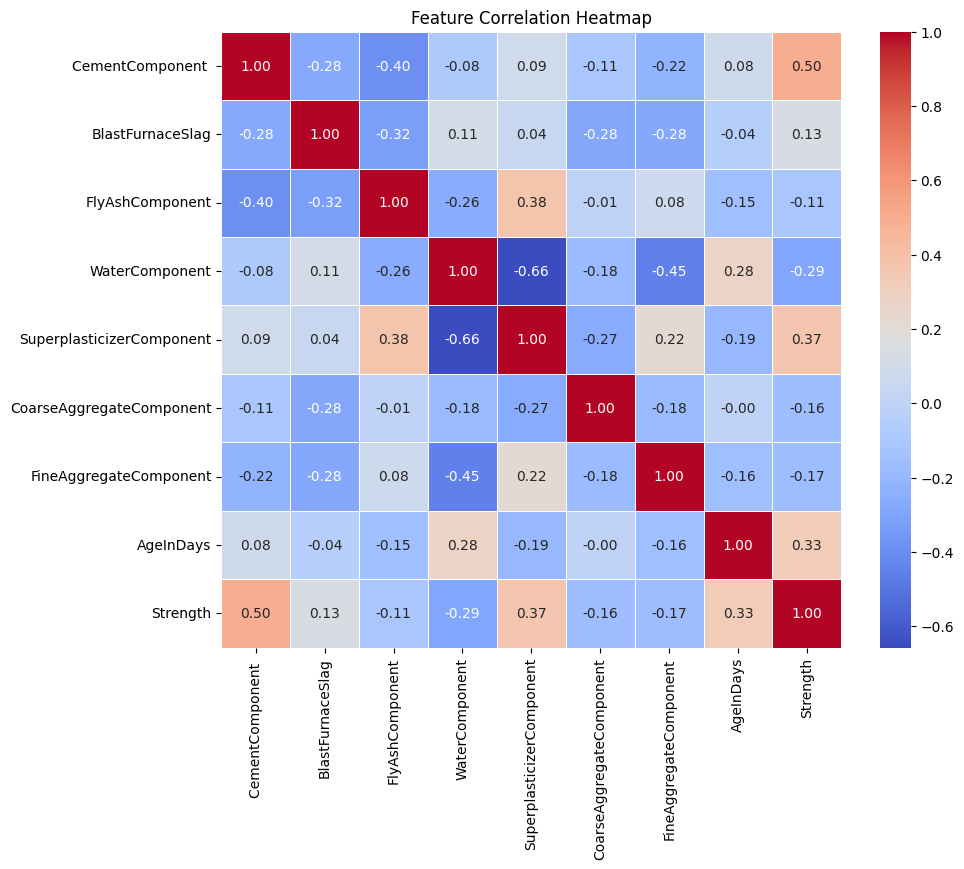

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
correlation_target = corr_matrix["Strength"]\
    .sort_values(ascending=False, key=np.abs)
print(correlation_target)

Strength                     1.000000
CementComponent              0.497832
SuperplasticizerComponent    0.366079
AgeInDays                    0.328873
WaterComponent              -0.289633
FineAggregateComponent      -0.167241
CoarseAggregateComponent    -0.164935
BlastFurnaceSlag             0.134829
FlyAshComponent             -0.105755
Name: Strength, dtype: float64


In [ ]:
strong_corr_pairs = []
threshold = 0.6

for i, col in enumerate(corr_matrix.columns):
    for row in corr_matrix.index[i + 1:]:
        if row != col and abs(corr_matrix.loc[row, col]) > threshold:
            strong_corr_pairs.append((row, col, corr_matrix.loc[row, col]))

if strong_corr_pairs:
    for pair in strong_corr_pairs:
        print(f"{pair[0]}, {pair[1]} | {pair[2]:.2f}")
else:
    print("There is no strong correlation.")

SuperplasticizerComponent, WaterComponent | -0.66


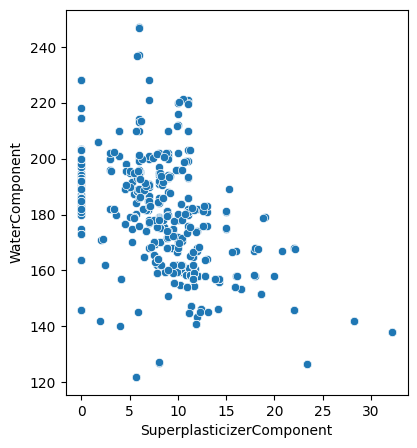

In [ ]:
plt.figure(figsize=(15, 5))
for pair in strong_corr_pairs:
    plt.subplot(1, 3, 1)
    sns.scatterplot(x=df[pair[0]], y=df[pair[1]])
    plt.xlabel(pair[0])
    plt.ylabel(pair[1])

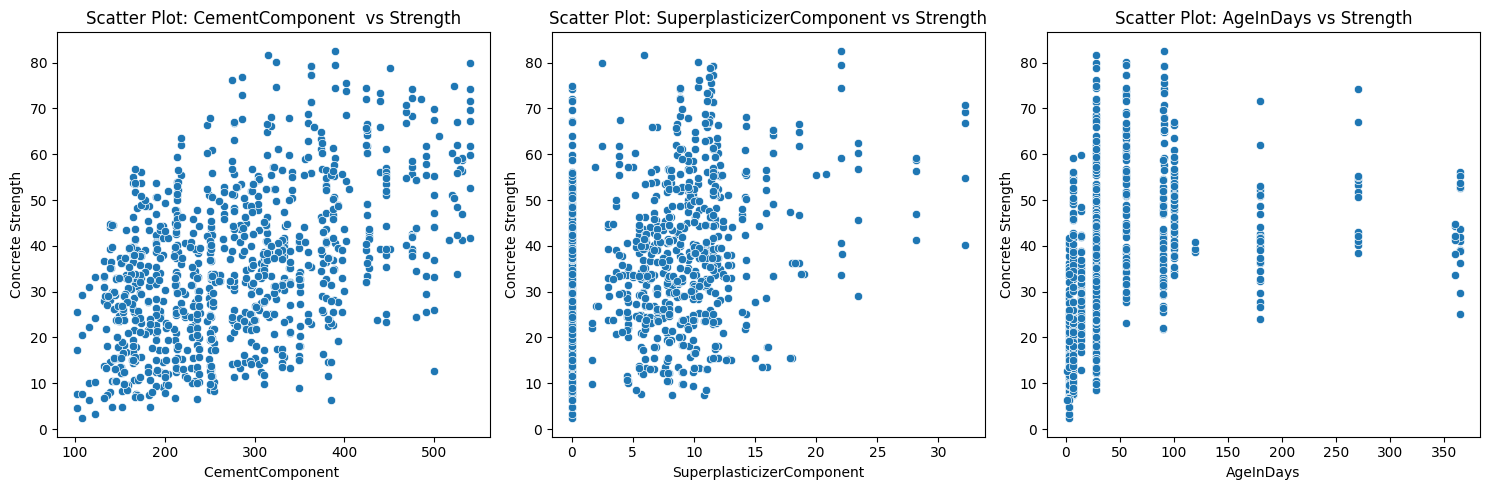

In [ ]:
key_features = correlation_target.index[1:4]

plt.figure(figsize=(15, 5))
for i, feature in enumerate(key_features, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=df[feature], y=df["Strength"])
    plt.xlabel(feature)
    plt.ylabel("Concrete Strength")
    plt.title(f"Scatter Plot: {feature} vs Strength")

plt.tight_layout()
plt.show()


### Section 3: Building and Evaluating the MLP Model

In [ ]:
X = df.drop("Strength", axis=1).values
y = df["Strength"]

In [ ]:
X

array([[ 540. ,    0. ,    0. , ..., 1040. ,  676. ,   28. ],
       [ 540. ,    0. ,    0. , ..., 1055. ,  676. ,   28. ],
       [ 332.5,  142.5,    0. , ...,  932. ,  594. ,  270. ],
       ...,
       [ 148.5,  139.4,  108.6, ...,  892.4,  780. ,   28. ],
       [ 159.1,  186.7,    0. , ...,  989.6,  788.9,   28. ],
       [ 260.9,  100.5,   78.3, ...,  864.5,  761.5,   28. ]])

In [ ]:
y

,Strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30
...,...
1025,44.28
1026,31.18
1027,23.70
1028,32.77


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def create_model(hidden_neurons=16, optimizer='adam', loss='mse', delta=1):
    model = Sequential([
        Dense(hidden_neurons, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(1, activation='linear')
    ])

    if loss == 'huber':
        loss = tf.keras.losses.Huber(delta)

    model.compile(optimizer=optimizer, loss=loss, metrics=['mse', 'mae', tf.keras.losses.Huber(delta)])
    return model

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test, verbose=0)
    return {
        'mse': mean_squared_error(y_test, y_pred),
        'mae': mean_absolute_error(y_test, y_pred)
    }

In [ ]:
def plot_training_history(history, model_name="Model"):
    # mapping: model_key = (epochs, hidden_layer, optimizer, loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label=f'MSE - Train', linestyle='dashed', color='blue')
    plt.plot(history.history['val_loss'], label=f'MSE - Test', color='blue')
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(f"MSE over Epochs; E={model_name[0]}, HL={model_name[1]}, O={model_name[2]}, L={model_name[3]}")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label=f'MAE - Train', linestyle='dashed', color='orange')
    plt.plot(history.history['val_mae'], label=f'MAE - Test', color='orange')
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title(f"MAE over Epochs; E={model_name[0]}, HL={model_name[1]}, O={model_name[2]}, L={model_name[3]}")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
epochs = 50
optimizer = 'adam'
loss = 'mse'
layer_models = dict()
layer_histories = dict()

for hidden_layer in [16, 32]:
    model_key = (epochs, hidden_layer, optimizer, loss)
    layer_models[model_key] = create_model(hidden_layer, optimizer, loss)
    layer_histories[model_key] = layer_models[model_key].fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), verbose=0)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
for model in layer_models:
    print(f'{model[1]} hidden layers: {evaluate(layer_models[model], X_test, y_test)}')

16 hidden layers: {'mse': 228.16739181643283, 'mae': 12.150709571714927}
32 hidden layers: {'mse': 160.03426656490765, 'mae': 10.162522009815598}


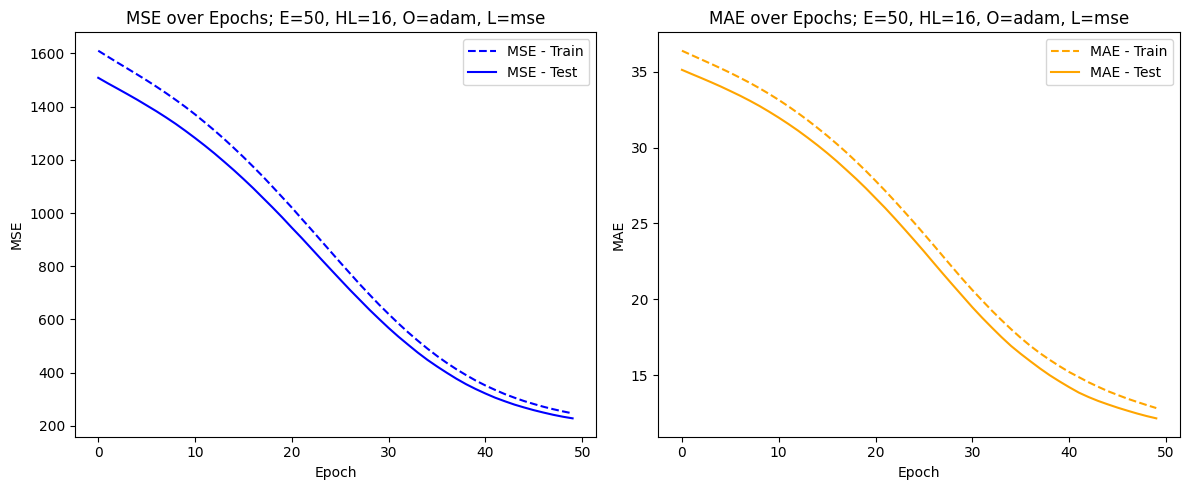

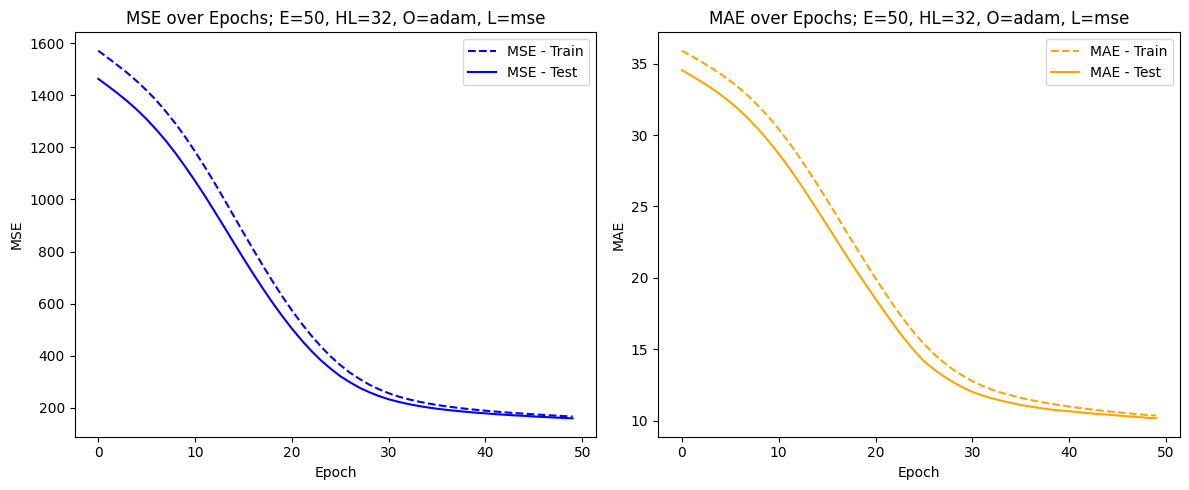

In [ ]:
for h in layer_histories:
    plt.figure(figsize=(12, 5))
    plot_training_history(layer_histories[h], h)

=======================

In [ ]:
hidden_layer = 16
optimizer = 'adam'
loss = 'mse'
epochs_models = dict()
epochs_histories = dict()

for epochs in [20, 50, 100, 500]:
    model_key = (epochs, hidden_layer, optimizer, loss)
    epochs_models[model_key] = create_model(hidden_layer, optimizer, loss)
    epochs_histories[model_key] = epochs_models[model_key].fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), verbose=0)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

In [ ]:
for model in epochs_models:
    print(f'{model[0]} epochs: {evaluate(epochs_models[model], X_test, y_test)}')

20 epochs: {'mse': 900.7910413215509, 'mae': 26.089891668492534}
50 epochs: {'mse': 207.17505476888542, 'mae': 11.345004650720886}
100 epochs: {'mse': 140.59878858374083, 'mae': 9.536684915733955}
500 epochs: {'mse': 45.58108030132412, 'mae': 5.1394140459573}


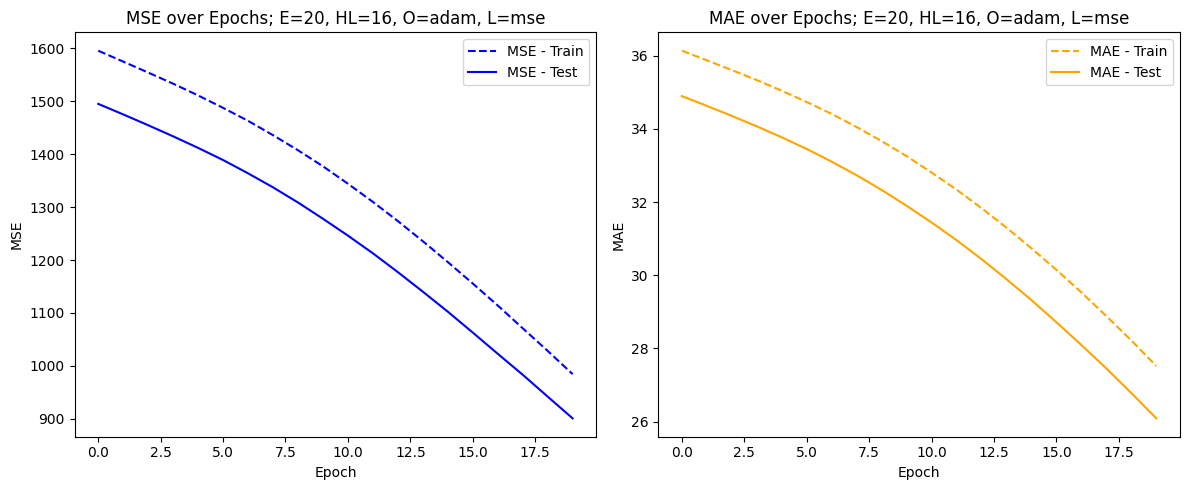

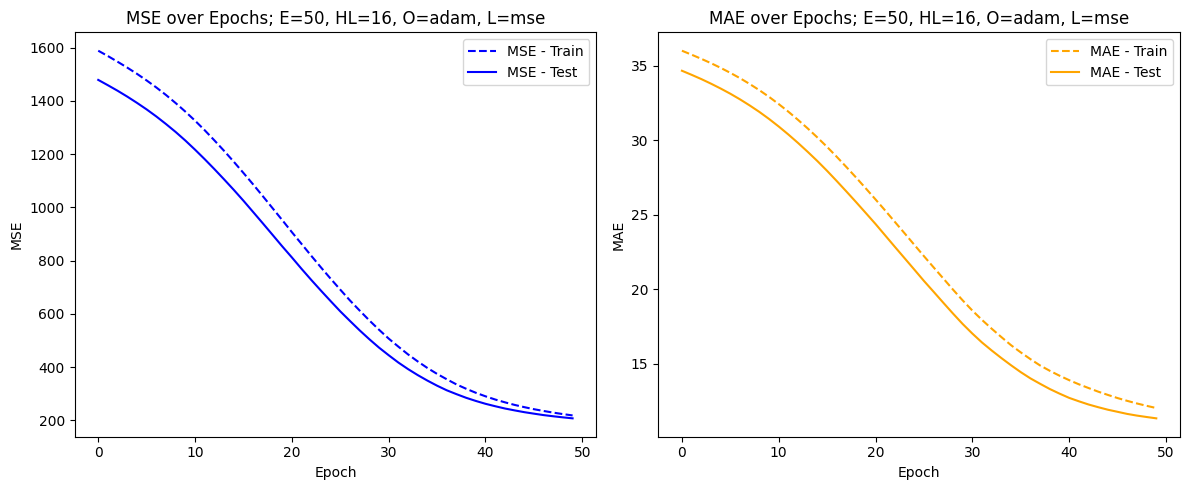

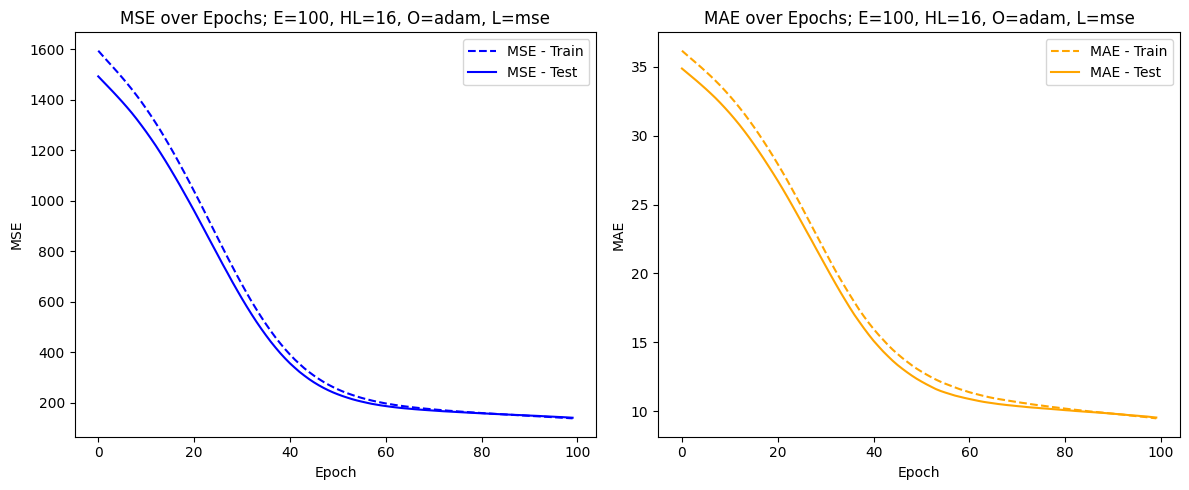

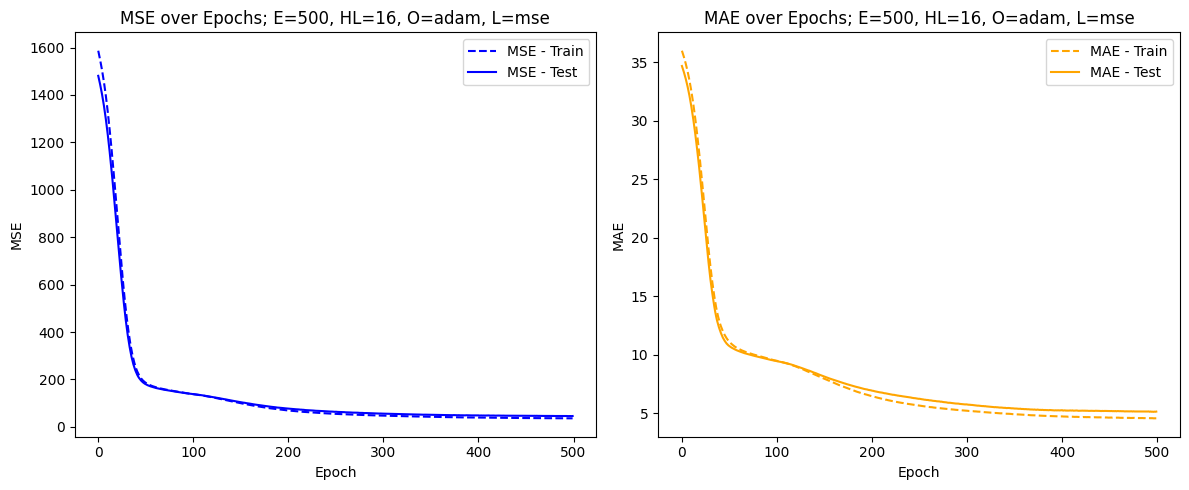

In [ ]:
for h in epochs_histories:
    plt.figure(figsize=(12, 5))
    plot_training_history(epochs_histories[h], h)

It is better to show the result only on the max. epoch (which includes the less ones)

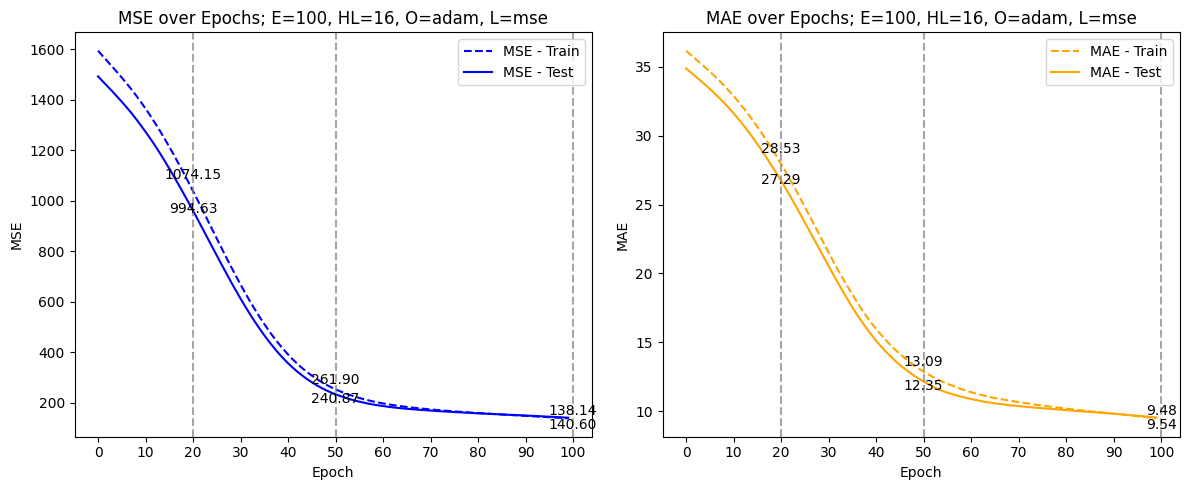

In [ ]:
e100_model_key = (100, 16, 'adam', 'mse')
h100 = epochs_histories[e100_model_key]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(h100.history['loss'], label=f'MSE - Train', linestyle='dashed', color='blue')
plt.plot(h100.history['val_loss'], label=f'MSE - Test', color='blue')
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title(f"MSE over Epochs; E={e100_model_key[0]}, HL={e100_model_key[1]}, O={e100_model_key[2]}, L={e100_model_key[3]}")
plt.legend()

for epoch in [20, 50, 100]:
    mse_train = h100.history['loss'][epoch - 1]
    mse_test = h100.history['val_loss'][epoch - 1]

    plt.axvline(x=epoch, color='gray', linestyle='--', alpha=0.7)
    plt.text(epoch, mse_train, f'{mse_train:.2f}', ha='center', va='bottom', color='black')
    plt.text(epoch, mse_test, f'{mse_test:.2f}', ha='center', va='top', color='black')

plt.xticks(np.arange(0, 101, 10))

plt.subplot(1, 2, 2)
plt.plot(h100.history['mae'], label=f'MAE - Train', linestyle='dashed', color='orange')
plt.plot(h100.history['val_mae'], label=f'MAE - Test', color='orange')
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title(f"MAE over Epochs; E={e100_model_key[0]}, HL={e100_model_key[1]}, O={e100_model_key[2]}, L={e100_model_key[3]}")
plt.legend()

for epoch in [20, 50, 100]:
    mae_train = h100.history['mae'][epoch - 1]
    mae_test = h100.history['val_mae'][epoch - 1]

    plt.axvline(x=epoch, color='gray', linestyle='--', alpha=0.7)
    plt.text(epoch, mae_train, f'{mae_train:.2f}', ha='center', va='bottom', color='black')
    plt.text(epoch, mae_test, f'{mae_test:.2f}', ha='center', va='top', color='black')

plt.xticks(np.arange(0, 101, 10))

plt.tight_layout()
plt.show()

In [ ]:
epochs = 50
hidden_layer = 16
optimizer = 'adam'
loss_models = dict()
loss_histories = dict()
delta = 1


for loss in ['mse', 'mae', 'huber']:
    model_key = (epochs, hidden_layer, optimizer, loss)
    loss_models[model_key] = create_model(hidden_layer, optimizer, loss, delta=delta)
    loss_histories[model_key] = loss_models[model_key].fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), verbose=0)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


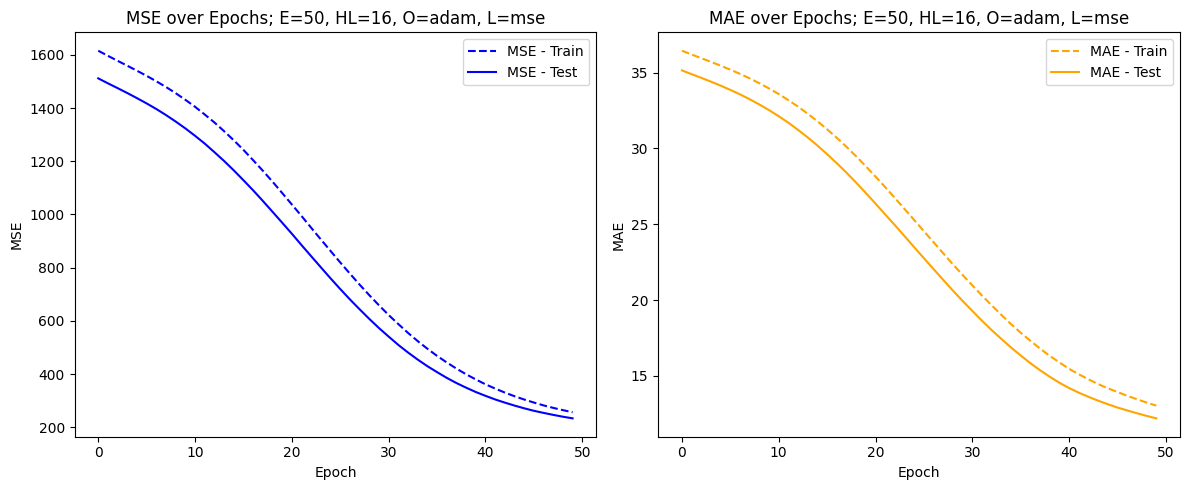

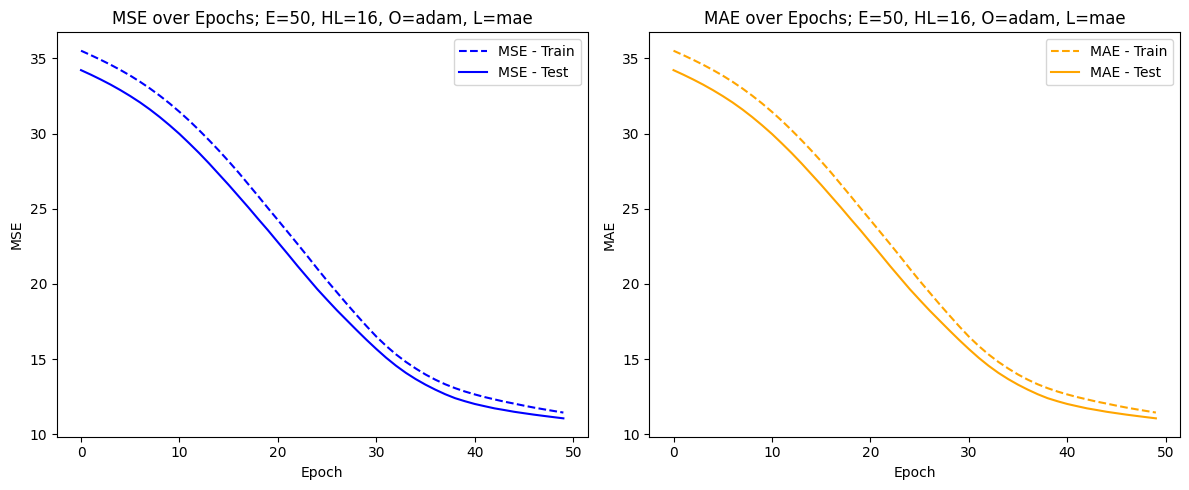

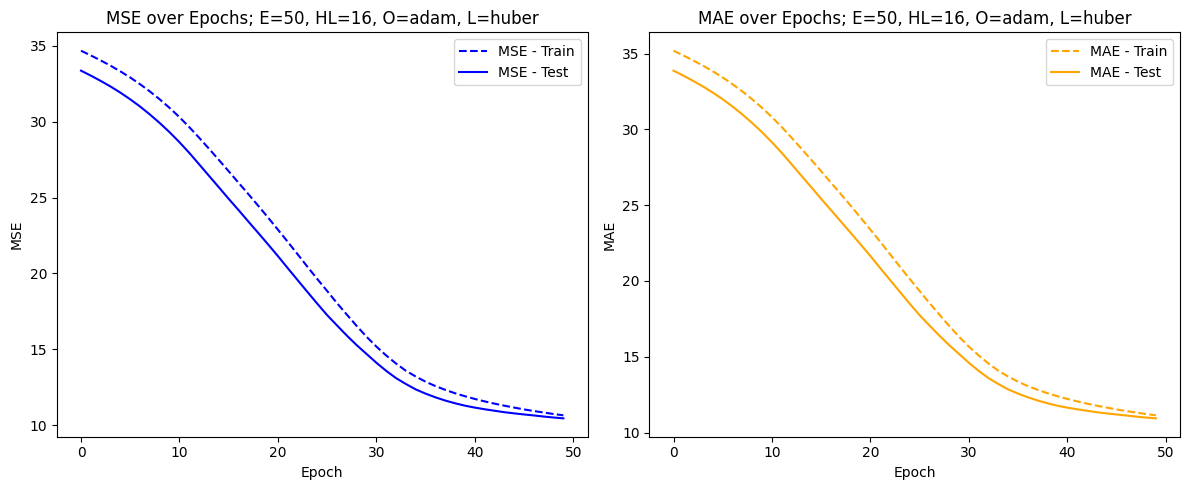

In [ ]:
for h in loss_histories:
    plt.figure(figsize=(12, 5))
    plot_training_history(loss_histories[h], h)
plt.show()

In [ ]:
epochs = 50
hidden_layer = 16
optimizer = 'adam'
delta = 1

result = []
for delta in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
    model = create_model(hidden_layer, optimizer, loss, delta=delta)
    history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), verbose=0)
    result.append((delta, evaluate(model, X_test, y_test)))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

In [ ]:
for delta, ev in result:
    print(f"Delta: {delta}, Final Validation Loss: {ev}")

Delta: 0.01, Final Validation Loss: {'mse': 194.17925527811298, 'mae': 10.865871236486342}
Delta: 0.05, Final Validation Loss: {'mse': 221.97832516324755, 'mae': 11.644637519441376}
Delta: 0.1, Final Validation Loss: {'mse': 222.38461198545937, 'mae': 11.911621292756214}
Delta: 0.5, Final Validation Loss: {'mse': 205.1437903843929, 'mae': 11.47769577433762}
Delta: 1.0, Final Validation Loss: {'mse': 213.82493330962436, 'mae': 11.557510253387747}
Delta: 2.0, Final Validation Loss: {'mse': 227.39108636660453, 'mae': 11.726009095571573}
Delta: 5.0, Final Validation Loss: {'mse': 185.09819468434705, 'mae': 10.720769636654158}
Delta: 10.0, Final Validation Loss: {'mse': 202.2736028891477, 'mae': 11.157856588641417}


In [ ]:
hidden_layer = 16
epochs = 50
loss = 'mse'
optimizer_models = dict()
optimizer_histories = dict()


for optimizer in ['adam', 'sgd', 'rmsprop']:
    model_key = (epochs, hidden_layer, optimizer, loss)
    optimizer_models[model_key] = create_model(hidden_layer, optimizer, loss)
    optimizer_histories[model_key] = optimizer_models[model_key].fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), verbose=0)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
for model in optimizer_models:
    print(f'{model[2]}: {evaluate(optimizer_models[model], X_test, y_test)}')

adam: {'mse': 245.35576770389798, 'mae': 12.508892923867434}
sgd: {'mse': 67.50671372239675, 'mae': 6.54069748251955}
rmsprop: {'mse': 223.93394026115774, 'mae': 11.74024357261781}


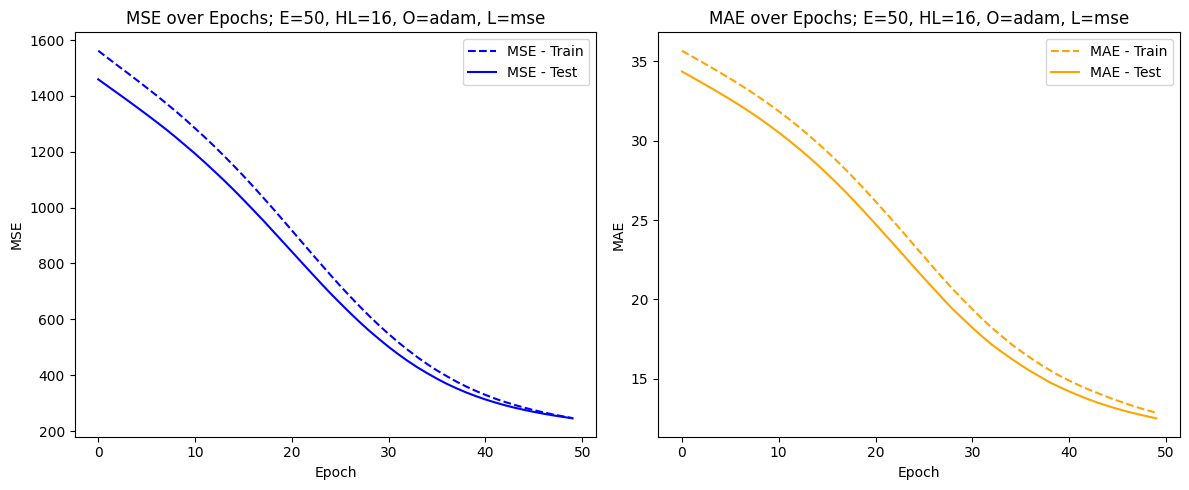

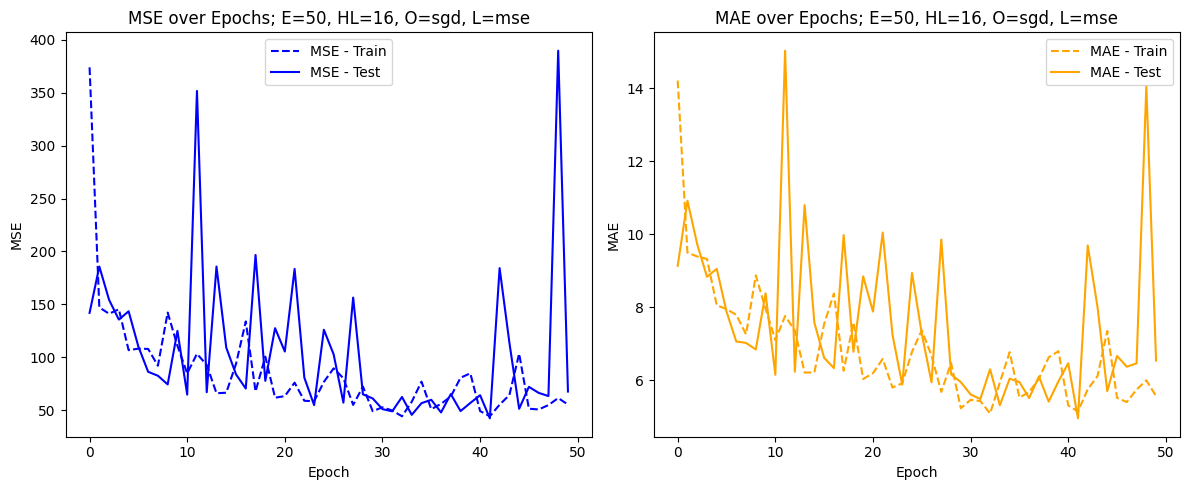

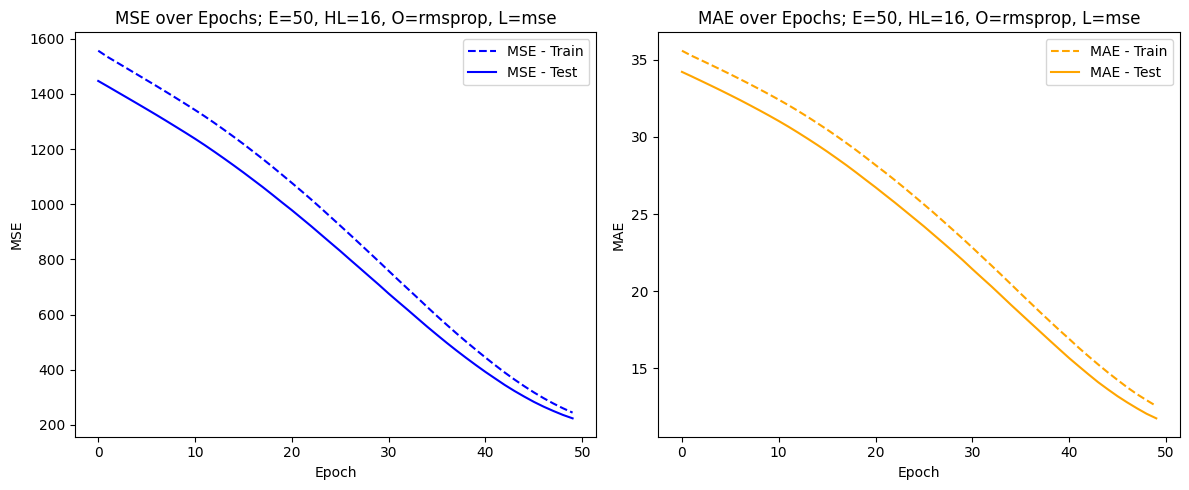

In [ ]:
for h in optimizer_histories:
    plt.figure(figsize=(12, 5))
    plot_training_history(optimizer_histories[h], h)

### Section 4: Wrap up:

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


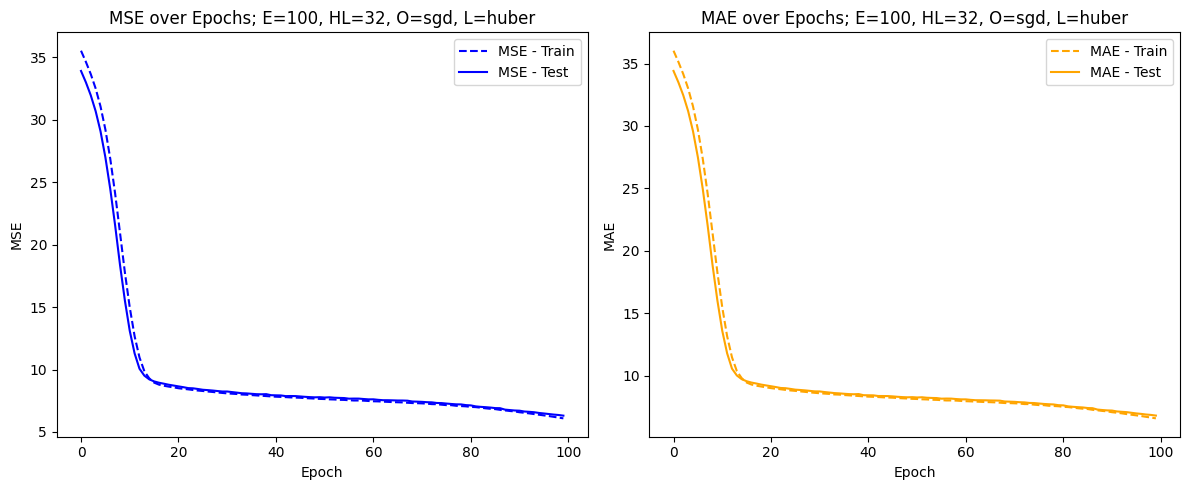

In [ ]:
hidden_layer = 32
epochs = 100
loss = 'huber'
delta = 1.0
optimizer = 'sgd'

model = create_model(hidden_layer, optimizer, loss, delta)
history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), verbose=0)

plt.figure(figsize=(12, 5))
plot_training_history(history, (epochs, hidden_layer, optimizer, loss))

In [ ]:
evaluate(model, X_test, y_test)

{'mse': 79.22871799580379, 'mae': 6.791554120011313}